### WEEK - 1
### Importing Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\91861\OneDrive\Desktop\IS_DA_IT\ScreenSense\Indian_Kids_Screen_Time.csv")

df.head()

df.info()

df.columns.tolist()
df.isnull().sum()

df.shape

df = df.where(pd.notnull(df), None)

df['Exceeded_Recommended_Limit'].value_counts()

# Duplicates
duplicates = df.duplicated().sum()
print("\nDuplicate rows:", duplicates)

df = df.drop_duplicates()
print("Shape after duplicate removal:", df.shape)
df['Health_Impacts'] = df['Health_Impacts'].fillna('No Health Impact')


df.isnull().sum()

df.describe()

df.describe(include='O')

df.Health_Impacts.unique()

df.isnull().sum()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB

Duplicate rows: 44
Shape after duplicate removal: (9668, 8)


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


### WEEK-2
### EDA - Exploratory Data Analysis
### Data Cleaning & Feature Engineering

## Handle Missing Values
### Finding:

Health_Impacts → ~33% missing

All other columns → 0% missing

In [5]:
df["Gender"] = df["Gender"].fillna("Unknown")
df["Primary_Device"] = df["Primary_Device"].fillna("Unknown")
df["Health_Impacts"] = df["Health_Impacts"].fillna("None")
df["Urban_or_Rural"] = df["Urban_or_Rural"].fillna("Unknown")

In [6]:
df.isnull().sum()

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

In [9]:
df["Age"].min(), df["Age"].max()

(8, 18)

In [27]:
df["Avg_Daily_Screen_Time_hr"] = df["Avg_Daily_Screen_Time_hr"].fillna(df["Avg_Daily_Screen_Time_hr"].median())

## Why median?¶
### Because screen time may have outlier

In [30]:
df["Gender"] = df["Gender"].str.strip()
df["Primary_Device"] = df["Primary_Device"].str.strip()
df["Health_Impacts"] = df["Health_Impacts"].str.strip()

## Create Age Groups

In [15]:
bins = [5,8,12,15,18]

labels = [
    "6-8",
    "9-12",
    "13-15",
    "16-18"
]


df["Age_Band"] = pd.cut(df["Age"], bins=bins, labels=labels)

 ## Create Screen Usage Category

In [36]:
df["Screen_Time_Category"] = pd.cut(
    df["Avg_Daily_Screen_Time_hr"],
    bins=[0,2,4,10],
    labels=["Low","Moderate","High"]
)

### Low → <2 hours

### Moderate → 2–4 hours

### High → >4 hours

In [17]:
#Device Share Feature
df['Is_Mobile_Device'] = df['Primary_Device'].apply(
    lambda x: 1 if x in ['Smartphone', 'Tablet'] else 0
)

In [106]:
df['Day_Type'] = df['Avg_Daily_Screen_Time_hr'].apply(
    lambda x: 'Weekend' if x > 4 else 'Weekday'
)

In [19]:
def device_group(x):
    if x in ['Smartphone', 'Tablet']:
        return 'Mobile'
    elif x in ['Laptop', 'Desktop']:
        return 'Computer'
    else:
        return 'Other'

df['Device_Category'] = df['Primary_Device'].apply(device_group)

In [21]:
### Educational vs Recreational Flag
df['Learning_Heavy_User'] = df['Educational_to_Recreational_Ratio'].apply(
    lambda x: 1 if x >= 0.5 else 0
)

In [23]:
#Health Risk Indicator
df['Health_Risk_Flag'] = df['Avg_Daily_Screen_Time_hr'].apply(
    lambda x: 1 if x > 4 else 0
)

In [25]:
df['User_Type'] = df['Educational_to_Recreational_Ratio'].apply(
    lambda x: 'Learning-Dominant' if x >= 0.5 else 'Recreation-Dominant'
)

# Save Cleaned Dataset

In [28]:
df.to_csv("cleaned_kids_screen_time.csv", index=False)

# Univariate Analysis

### Univariate analysis studies one variable at a time.

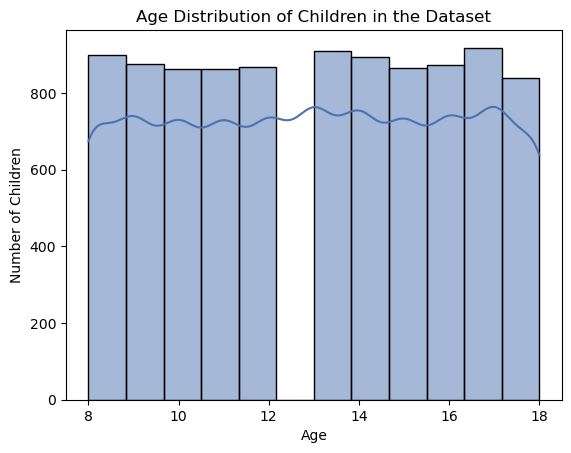

In [31]:
plt.figure()

sns.histplot(
    df["Age"],
    bins=12,
    kde=True,
    color="#4C72B0"
)

plt.title("Age Distribution of Children in the Dataset")
plt.xlabel("Age")
plt.ylabel("Number of Children")

plt.show()

**The dataset contains children across different age groups, with most observations concentrated within middle childhood and early teenage years.**

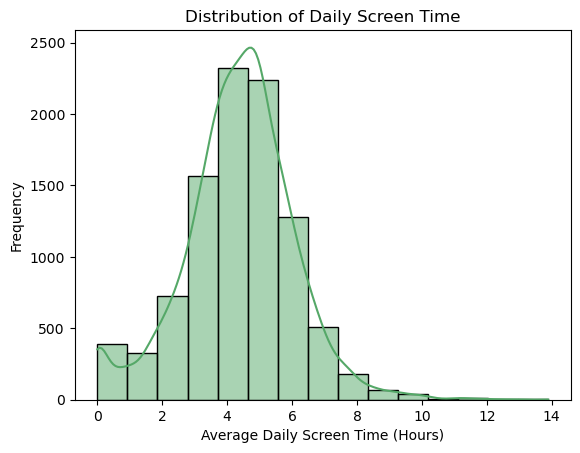

In [34]:
# Daily Screen Time Distribution
plt.figure()

sns.histplot(
    df["Avg_Daily_Screen_Time_hr"],
    bins=15,
    kde=True,
    color="#55A868"
)

plt.title("Distribution of Daily Screen Time")
plt.xlabel("Average Daily Screen Time (Hours)")
plt.ylabel("Frequency")

plt.show()

**Most children spend 2–4 hours daily on screens.**

**A smaller segment exceeds 5 hours, indicating possible excessive use.**

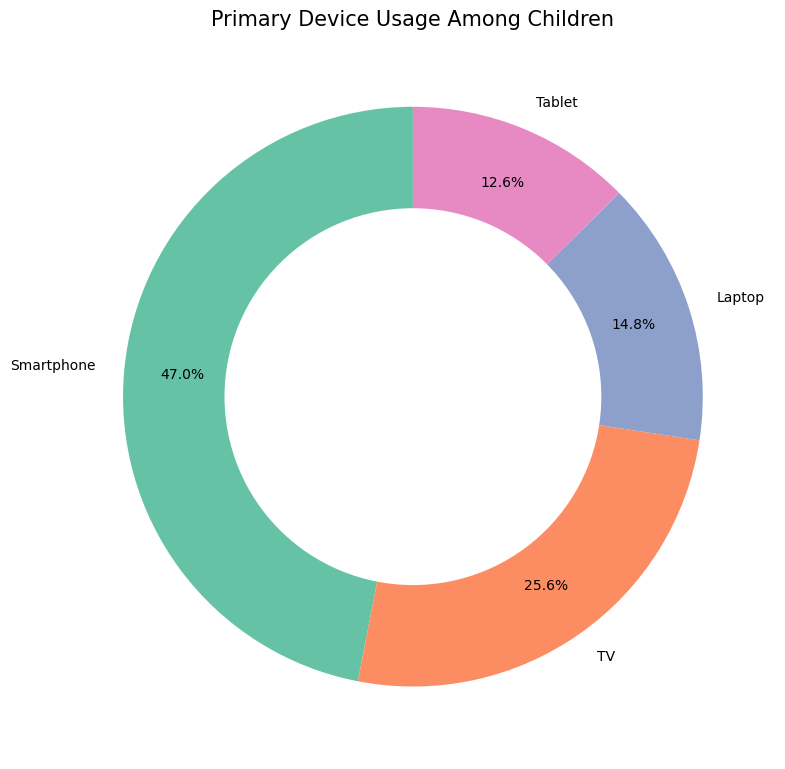

In [37]:
# Device Usage Share
device_counts = df["Primary_Device"].value_counts()

plt.figure(figsize=(8,8))

colors = sns.color_palette("Set2", len(device_counts))

plt.pie(
    device_counts.values,
    labels=device_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.8,   # percentage position
    labeldistance=1.1  # label position
)

# create white circle for donut
centre_circle = plt.Circle((0,0),0.65,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Primary Device Usage Among Children", fontsize=15)

plt.tight_layout()
plt.show()

**Smartphones dominate children’s device usage.**

**Tablets and laptops represent smaller shares of daily interaction.**

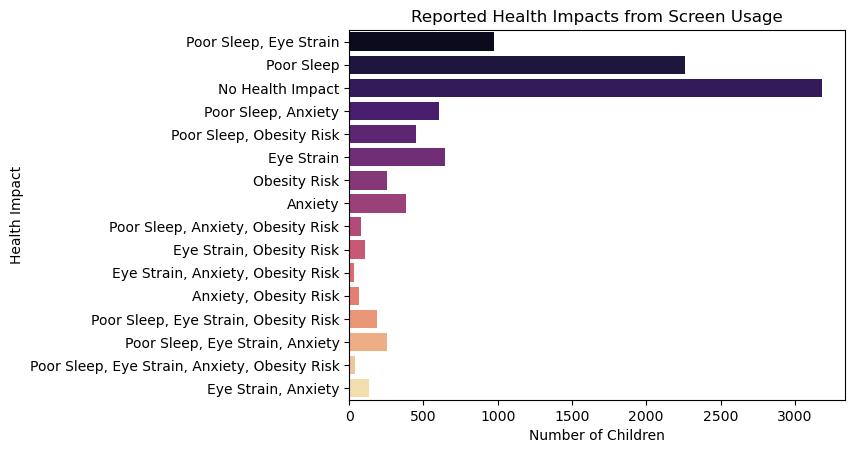

In [40]:
#Health Impact Frequency
plt.figure()

sns.countplot(
    y="Health_Impacts",
    data=df,
    palette="magma"
)

plt.title("Reported Health Impacts from Screen Usage")
plt.xlabel("Number of Children")
plt.ylabel("Health Impact")

plt.show()

**Eye strain and sleep disturbances appear frequently.**

**This suggests prolonged screen exposure may affect children's well-being.**

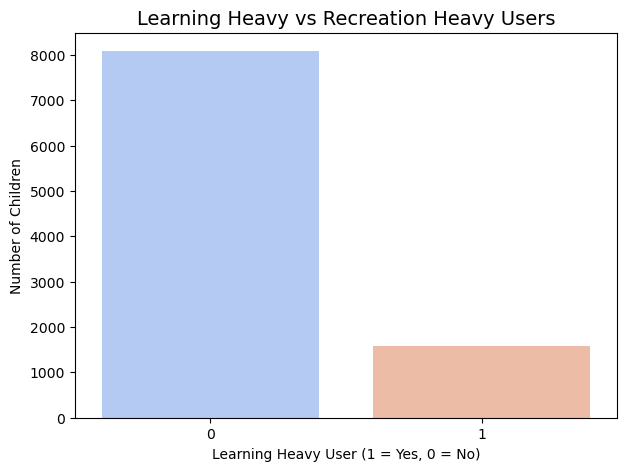

In [63]:


plt.figure(figsize=(7,5))
sns.countplot(
    x='Learning_Heavy_User',
    data=df,
    palette='coolwarm'
)

plt.title("Learning Heavy vs Recreation Heavy Users", fontsize=14)
plt.xlabel("Learning Heavy User (1 = Yes, 0 = No)")
plt.ylabel("Number of Children")

plt.show()

**Shows proportion of learning focused vs entertainment focused usage**

**If 0 dominates → most children use devices mainly for recreation**

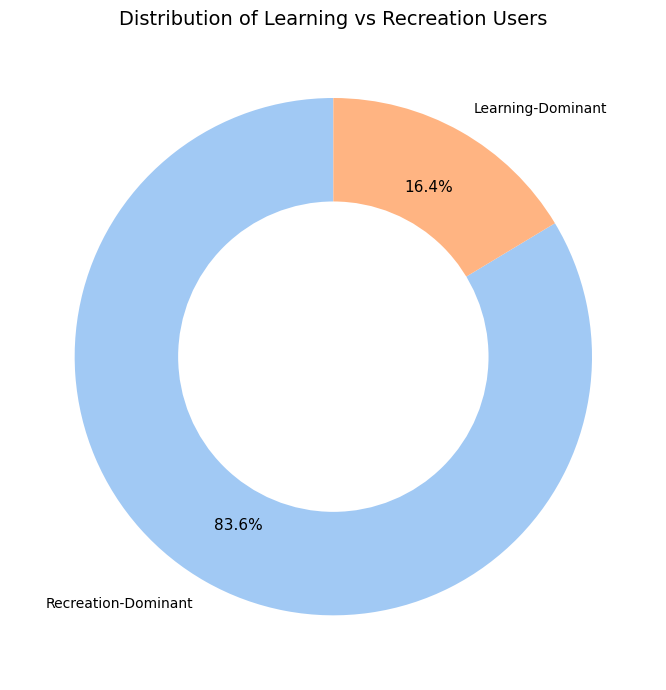

In [71]:
user_counts = df['User_Type'].value_counts()

plt.figure(figsize=(7,7))

colors = sns.color_palette("pastel")

wedges, texts, autotexts = plt.pie(
    user_counts.values,
    labels=user_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,   
    labeldistance=1.1
)

# Make percentage text clearer
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(11)

# Donut hole
centre_circle = plt.Circle((0,0),0.6,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Distribution of Learning vs Recreation Users", fontsize=14)

plt.tight_layout()
plt.show()

**Shows dominant screen usage behavior**

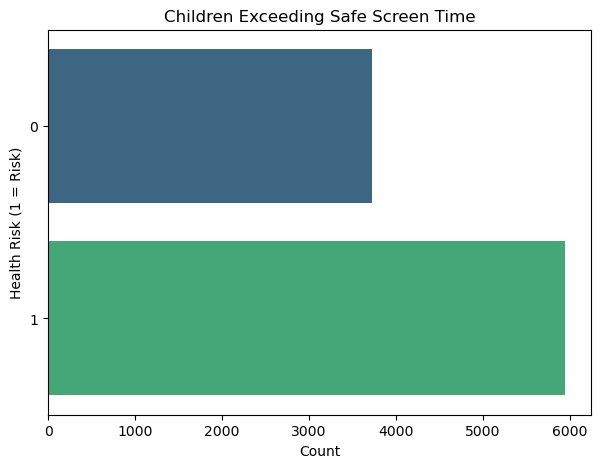

In [75]:
plt.figure(figsize=(7,5))

sns.countplot(
    y='Health_Risk_Flag',
    data=df,
    palette='viridis'
)

plt.title("Children Exceeding Safe Screen Time")
plt.xlabel("Count")
plt.ylabel("Health Risk (1 = Risk)")

plt.show()

**Shows how many children exceed recommended screen time (>4 hrs)**

# Bivariate Analysis



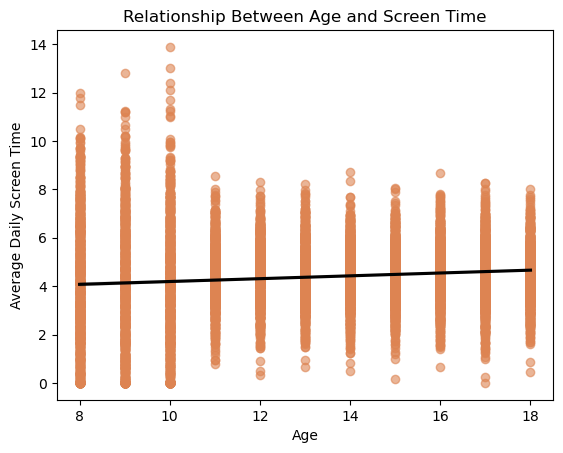

In [44]:
#Age vs Screen Time
plt.figure()

sns.regplot(
    x="Age",
    y="Avg_Daily_Screen_Time_hr",
    data=df,
    scatter_kws={"alpha":0.6,"color":"#DD8452"},
    line_kws={"color":"black"}
)

plt.title("Relationship Between Age and Screen Time")
plt.xlabel("Age")
plt.ylabel("Average Daily Screen Time")

plt.show()

**Screen time shows a mild increasing trend with age.**

**Older children likely have more autonomy in device usage.**

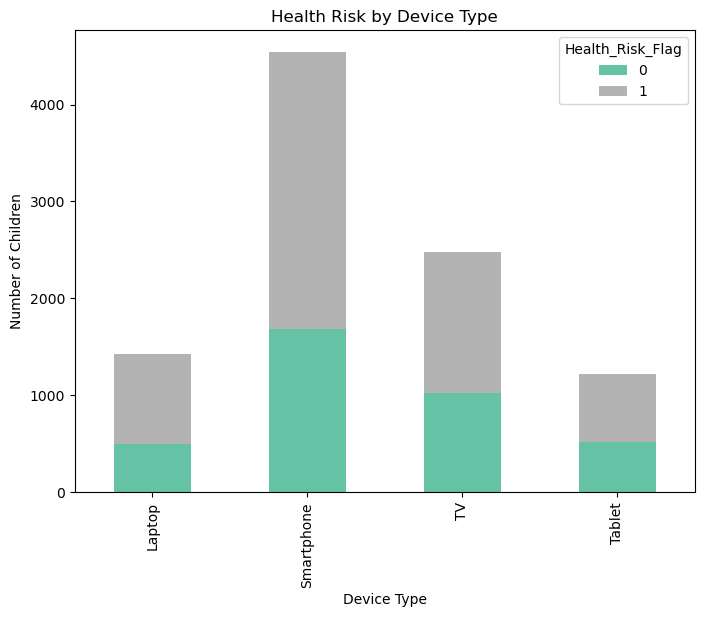

In [78]:
risk_device = pd.crosstab(df['Primary_Device'], df['Health_Risk_Flag'])

risk_device.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    colormap='Set2'
)

plt.title("Health Risk by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Children")

plt.show()

**Identifies devices linked to high screen time**

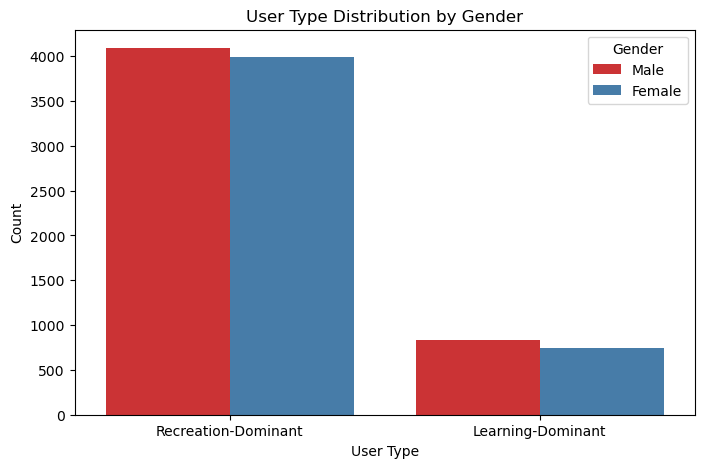

In [81]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='User_Type',
    hue='Gender',
    data=df,
    palette='Set1'
)

plt.title("User Type Distribution by Gender")
plt.xlabel("User Type")
plt.ylabel("Count")

plt.show()

**Compare learning vs recreation preference across genders**

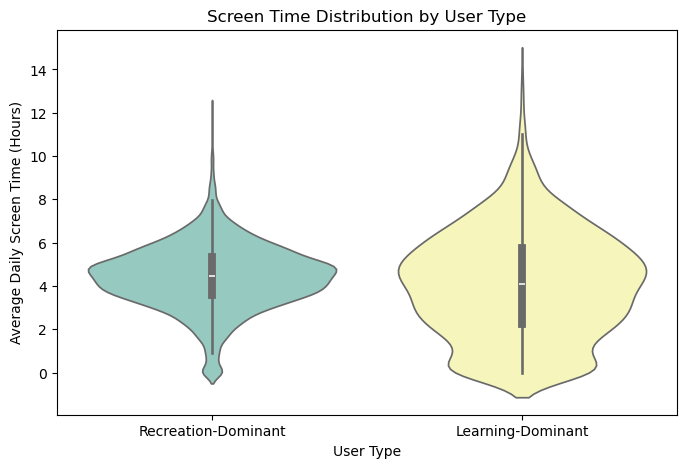

In [84]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='User_Type',
    y='Avg_Daily_Screen_Time_hr',
    data=df,
    palette='Set3'
)

plt.title("Screen Time Distribution by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Daily Screen Time (Hours)")

plt.show()

**Shows distribution shape of screen time**

**Recreation-dominant users may show higher variability**


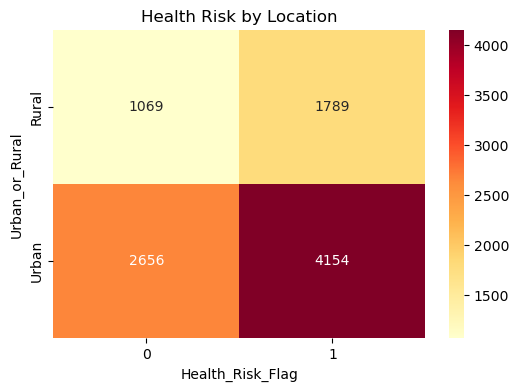

In [87]:
risk_location = pd.crosstab(df['Urban_or_Rural'], df['Health_Risk_Flag'])

plt.figure(figsize=(6,4))

sns.heatmap(
    risk_location,
    annot=True,
    cmap="YlOrRd",
    fmt='d'
)

plt.title("Health Risk by Location")

plt.show()

##### Shows whether urban or rural kids face more screen-time risk

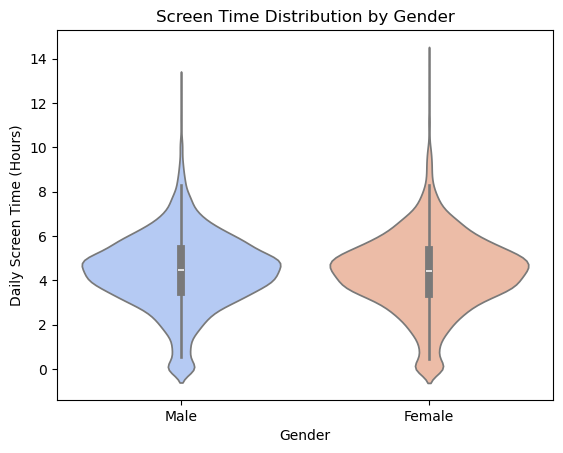

In [90]:
#Gender vs Screen Time
plt.figure()

sns.violinplot(
    x="Gender",
    y="Avg_Daily_Screen_Time_hr",
    data=df,
    palette="coolwarm"
)

plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

**Screen time distributions between genders appear broadly similar.**

**Slight variation in distribution suggests behavioral differences.**

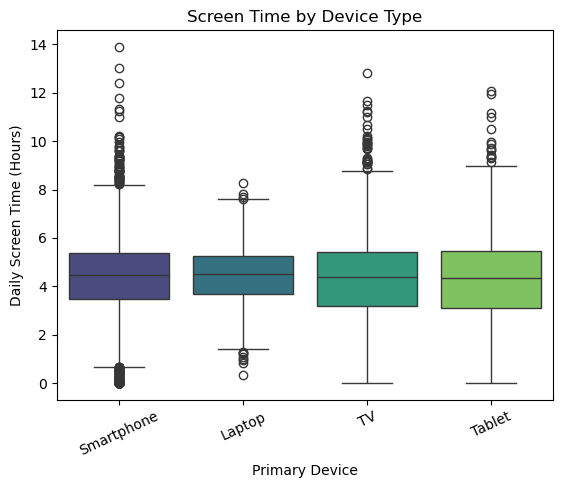

In [93]:
#Device vs Screen Time

plt.figure()

sns.boxplot(
    x="Primary_Device",
    y="Avg_Daily_Screen_Time_hr",
    data=df,
    palette="viridis"
)

plt.title("Screen Time by Device Type")
plt.xlabel("Primary Device")
plt.ylabel("Daily Screen Time (Hours)")

plt.xticks(rotation=25)

plt.show()

**Smartphones show higher variability in screen time.**

**Portable devices may encourage longer usage sessions.**

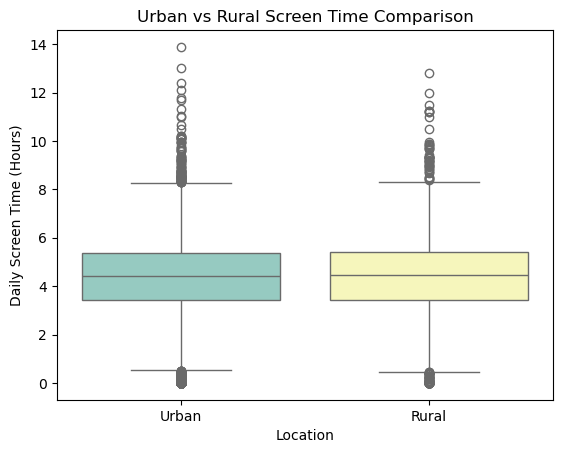

In [96]:
# Urban vs Rural Screen Time

plt.figure()

sns.boxplot(
    x="Urban_or_Rural",
    y="Avg_Daily_Screen_Time_hr",
    data=df,
    palette="Set3"
)

plt.title("Urban vs Rural Screen Time Comparison")
plt.xlabel("Location")
plt.ylabel("Daily Screen Time (Hours)")

plt.show()

**Urban children tend to exhibit slightly higher screen exposure.**

**This could be related to greater device availability.**

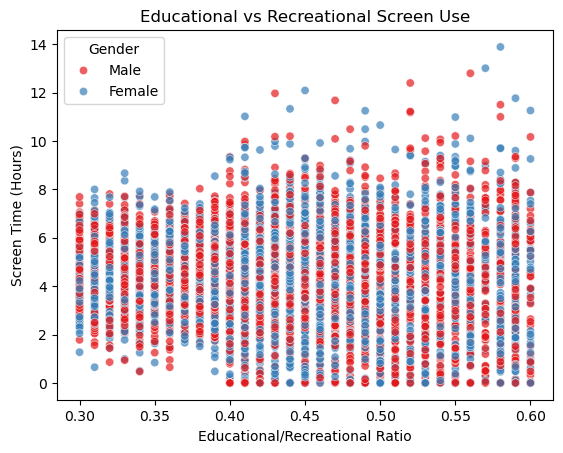

In [99]:
#Educational Ratio vs Screen Time
plt.figure()

sns.scatterplot(
    x="Educational_to_Recreational_Ratio",
    y="Avg_Daily_Screen_Time_hr",
    data=df,
    hue="Gender",
    palette="Set1",
    alpha=0.7
)

plt.title("Educational vs Recreational Screen Use")
plt.xlabel("Educational/Recreational Ratio")
plt.ylabel("Screen Time (Hours)")

plt.show()

**Lower ratios indicate dominance of recreational usage.**


**Educational screen usage tends to occur in moderate screen-time ranges.**

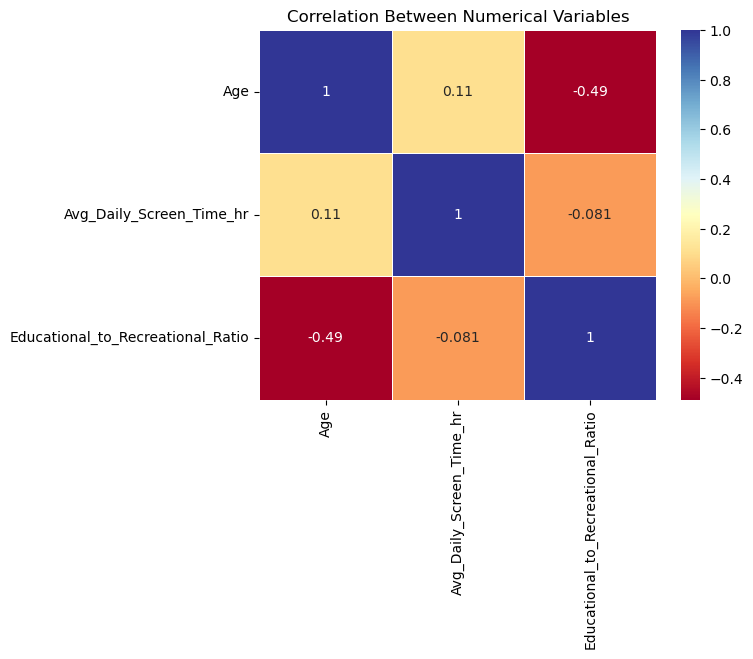

In [102]:
#Correlation Heatmap


plt.figure()

corr = df[["Age","Avg_Daily_Screen_Time_hr","Educational_to_Recreational_Ratio"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Variables")

plt.show()

**Screen time shows moderate relationships with other behavioral variables.**

**Correlation analysis helps identify patterns for deeper study.**

## EDA SUMMARY
1.The dataset contains 9712 records and 8 columns.


2.The age of students ranges from 8 to 18 years, with an average age of around 13 years.


3.The gender distribution is nearly balanced between male and female students.


4.The average daily screen time is around 4 to 5 hours, with some students reaching up to 13+ hours.

5.A significant number of students have exceeded the recommended screen time limit.


6.The Educational to Recreational screen time ratio suggests slightly more time is spent on recreational activities.


7.The dataset contains missing values in the 'Health_Impacts' column, while other columns have complete data.


8.Overall, the dataset shows that high screen time is common among students and may be associated with health issues such as poor sleep and eye strain.